# ⚖️ Détection et Quantification des Biais

Ce notebook implémente les métriques de fairness standards pour analyser les biais dans le modèle baseline TF-IDF + Random Forest.

In [13]:
# Cellule 1: Setup et chargement du modèle baseline
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from scipy import stats
import json
from collections import defaultdict

print("⚖️ DÉTECTION ET QUANTIFICATION DES BIAIS")
print("=" * 50)

# Charger le modèle et données
with open('baseline_model.pkl', 'rb') as f:
    baseline_model = pickle.load(f)

with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

print("✅ Modèle baseline chargé")
print(f"📋 Classes: {list(le.classes_)}")

⚖️ DÉTECTION ET QUANTIFICATION DES BIAIS
✅ Modèle baseline chargé
📋 Classes: [np.str_('dentist'), np.str_('nurse'), np.str_('physician'), np.str_('psychologist'), np.str_('surgeon')]


In [14]:
# Cellule 2: Charger et préparer les données de test
def load_jsonl(file_path):
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

# Charger test set
test_set = load_jsonl('medical_bios_data/test.jsonl')
df_test = pd.DataFrame(test_set)

# Préparer les données
X_test = df_test['full_text'].fillna('')
y_test = le.transform(df_test['title'])
test_pred = baseline_model.predict(X_test)
test_pred_proba = baseline_model.predict_proba(X_test)

print(f"✅ Test set: {len(df_test)} exemples")
print(f"📊 Distribution par genre:")
print(df_test['gender'].value_counts())
print(f"📊 Distribution par profession:")
print(df_test['title'].value_counts())

✅ Test set: 1000 exemples
📊 Distribution par genre:
gender
Female    540
Male      460
Name: count, dtype: int64
📊 Distribution par profession:
title
psychologist    279
dentist         197
nurse           195
physician       170
surgeon         159
Name: count, dtype: int64


## 🔍 Implémentation des Métriques de Fairness

In [20]:
# Cellule 3: Implémenter métriques fairness
def calculate_demographic_parity(y_pred, sensitive_attr):
    """∆DP = |P(Ŷ=class|A=male) - P(Ŷ=class|A=female)|"""
    results = {}
    groups = np.unique(sensitive_attr)
    
    for class_id in range(len(le.classes_)):
        class_rates = []
        for group in groups:
            group_mask = sensitive_attr == group
            if group_mask.sum() > 0:
                rate = np.mean(y_pred[group_mask] == class_id)
                class_rates.append(rate)
        
        if len(class_rates) == 2:
            results[le.classes_[class_id]] = {
                'male_rate': class_rates[0] if groups[0] == 'Male' else class_rates[1],
                'female_rate': class_rates[1] if groups[0] == 'Male' else class_rates[0],
                'gap': abs(class_rates[0] - class_rates[1])
            }
    
    return results

def calculate_equality_opportunity(y_true, y_pred, sensitive_attr):
    """∆EO = |TPR_male - TPR_female| pour chaque classe"""
    results = {}
    groups = np.unique(sensitive_attr)
    
    for class_id in range(len(le.classes_)):
        tprs = []
        for group in groups:
            group_mask = sensitive_attr == group
            class_mask = y_true == class_id
            combined_mask = group_mask & class_mask
            
            if combined_mask.sum() > 0:
                tpr = np.mean(y_pred[combined_mask] == class_id)
                tprs.append(tpr)
            else:
                tprs.append(0)
        
        if len(tprs) == 2:
            results[le.classes_[class_id]] = {
                'male_tpr': tprs[0] if groups[0] == 'Male' else tprs[1],
                'female_tpr': tprs[1] if groups[0] == 'Male' else tprs[0],
                'gap': abs(tprs[0] - tprs[1])
            }
    
    return results

def calculate_equalized_odds(y_true, y_pred, sensitive_attr):
    """∆EqOdds = max(|TPR_male - TPR_female|, |FPR_male - FPR_female|)"""
    results = {}
    groups = np.unique(sensitive_attr)
    
    for class_id in range(len(le.classes_)):
        tprs = []
        fprs = []
        
        for group in groups:
            group_mask = sensitive_attr == group
            
            # TPR
            true_positive_mask = group_mask & (y_true == class_id)
            if true_positive_mask.sum() > 0:
                tpr = np.mean(y_pred[true_positive_mask] == class_id)
                tprs.append(tpr)
            else:
                tprs.append(0)
            
            # FPR
            true_negative_mask = group_mask & (y_true != class_id)
            if true_negative_mask.sum() > 0:
                fpr = np.mean(y_pred[true_negative_mask] == class_id)
                fprs.append(fpr)
            else:
                fprs.append(0)
        
        if len(tprs) == 2 and len(fprs) == 2:
            tpr_gap = abs(tprs[0] - tprs[1])
            fpr_gap = abs(fprs[0] - fprs[1])
            
            results[le.classes_[class_id]] = {
                'tpr_gap': tpr_gap,
                'fpr_gap': fpr_gap,
                'max_gap': max(tpr_gap, fpr_gap)
            }
    
    return results

print("✅ Fonctions de fairness implémentées")

✅ Fonctions de fairness implémentées


## 📊 Calcul des Métriques de Fairness

In [21]:
# Cellule 4: Calculer toutes les métriques
genders = df_test['gender'].values

print("🔍 CALCUL DES MÉTRIQUES DE FAIRNESS")
print("=" * 40)

# Demographic Parity
dp_results = calculate_demographic_parity(test_pred, genders)
print("\n1️⃣ DEMOGRAPHIC PARITY (∆DP):")
for profession, metrics in dp_results.items():
    print(f"\n{profession}:")
    print(f"  Male rate: {metrics['male_rate']:.3f}")
    print(f"  Female rate: {metrics['female_rate']:.3f}")
    print(f"  Gap (∆DP): {metrics['gap']:.3f}")
    if metrics['gap'] > 0.1:  # Seuil de 10%
        print(f"  🚨 BIAIS DÉTECTÉ (gap > 10%)")
    else:
        print(f"  ✅ Acceptable")

# Equality of Opportunity
eo_results = calculate_equality_opportunity(y_test, test_pred, genders)
print("\n\n2️⃣ EQUALITY OF OPPORTUNITY (∆EO):")
for profession, metrics in eo_results.items():
    print(f"\n{profession}:")
    print(f"  Male TPR: {metrics['male_tpr']:.3f}")
    print(f"  Female TPR: {metrics['female_tpr']:.3f}")
    print(f"  Gap (∆EO): {metrics['gap']:.3f}")
    if metrics['gap'] > 0.1:
        print(f"  🚨 BIAIS DÉTECTÉ (gap > 10%)")
    else:
        print(f"  ✅ Acceptable")

# Equalized Odds
eqodds_results = calculate_equalized_odds(y_test, test_pred, genders)
print("\n\n3️⃣ EQUALIZED ODDS (∆EqOdds):")
for profession, metrics in eqodds_results.items():
    print(f"\n{profession}:")
    print(f"  TPR gap: {metrics['tpr_gap']:.3f}")
    print(f"  FPR gap: {metrics['fpr_gap']:.3f}")
    print(f"  Max gap (∆EqOdds): {metrics['max_gap']:.3f}")
    if metrics['max_gap'] > 0.1:
        print(f"  🚨 BIAIS DÉTECTÉ (gap > 10%)")
    else:
        print(f"  ✅ Acceptable")

🔍 CALCUL DES MÉTRIQUES DE FAIRNESS

1️⃣ DEMOGRAPHIC PARITY (∆DP):

dentist:
  Male rate: 0.283
  Female rate: 0.124
  Gap (∆DP): 0.159
  🚨 BIAIS DÉTECTÉ (gap > 10%)

nurse:
  Male rate: 0.035
  Female rate: 0.324
  Gap (∆DP): 0.289
  🚨 BIAIS DÉTECTÉ (gap > 10%)

physician:
  Male rate: 0.157
  Female rate: 0.178
  Gap (∆DP): 0.021
  ✅ Acceptable

psychologist:
  Male rate: 0.239
  Female rate: 0.326
  Gap (∆DP): 0.087
  ✅ Acceptable

surgeon:
  Male rate: 0.287
  Female rate: 0.048
  Gap (∆DP): 0.239
  🚨 BIAIS DÉTECTÉ (gap > 10%)


2️⃣ EQUALITY OF OPPORTUNITY (∆EO):

dentist:
  Male TPR: 1.000
  Female TPR: 1.000
  Gap (∆EO): 0.000
  ✅ Acceptable

nurse:
  Male TPR: 1.000
  Female TPR: 0.972
  Gap (∆EO): 0.028
  ✅ Acceptable

physician:
  Male TPR: 0.986
  Female TPR: 0.990
  Gap (∆EO): 0.003
  ✅ Acceptable

psychologist:
  Male TPR: 1.000
  Female TPR: 1.000
  Gap (∆EO): 0.000
  ✅ Acceptable

surgeon:
  Male TPR: 0.985
  Female TPR: 1.000
  Gap (∆EO): 0.015
  ✅ Acceptable


3️⃣ EQUALI

## 🔥 Matrices de Confusion par Genre

📈 MATRICES DE CONFUSION PAR GENRE


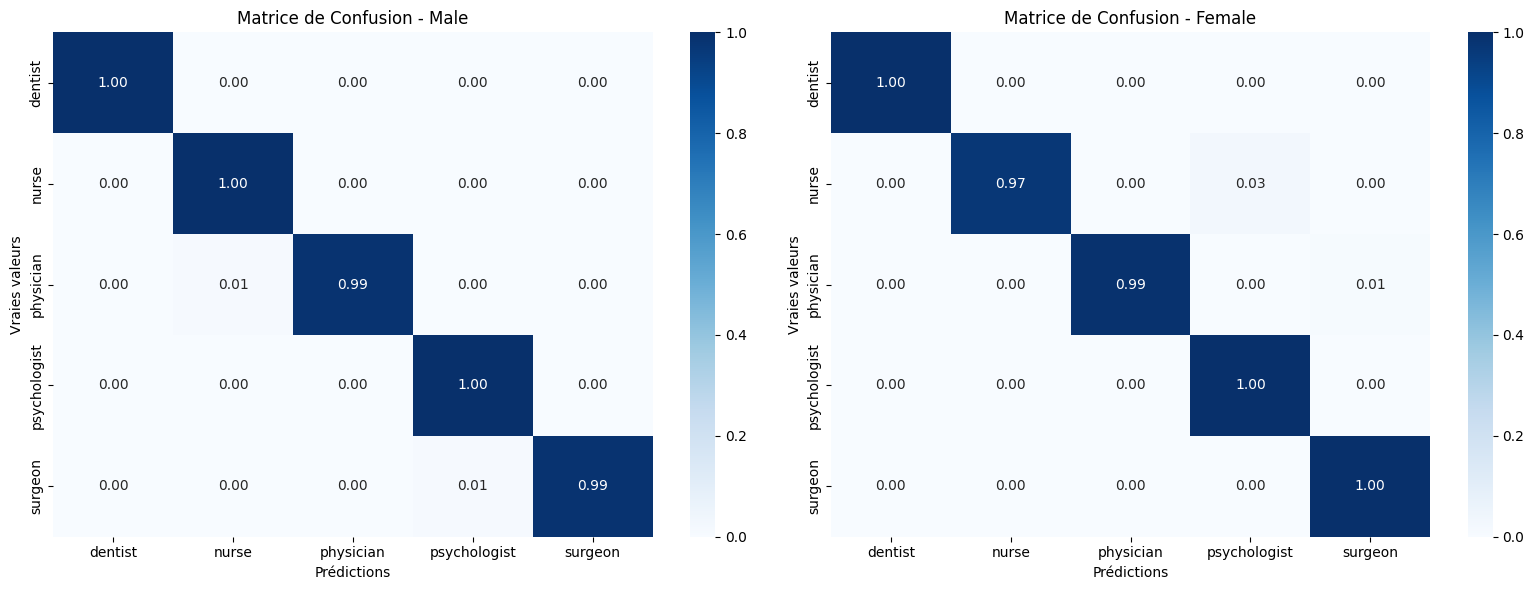


📊 MÉTRIQUES DÉTAILLÉES PAR GENRE:

=== MALE ===
              precision    recall  f1-score   support

     dentist       1.00      1.00      1.00       130
       nurse       0.94      1.00      0.97        15
   physician       1.00      0.99      0.99        73
psychologist       0.98      1.00      0.99       108
     surgeon       1.00      0.99      0.99       134

    accuracy                           0.99       460
   macro avg       0.98      0.99      0.99       460
weighted avg       0.99      0.99      0.99       460


=== FEMALE ===
              precision    recall  f1-score   support

     dentist       1.00      1.00      1.00        67
       nurse       1.00      0.97      0.99       180
   physician       1.00      0.99      0.99        97
psychologist       0.97      1.00      0.99       171
     surgeon       0.96      1.00      0.98        25

    accuracy                           0.99       540
   macro avg       0.99      0.99      0.99       540
weighted avg

In [25]:
# Cellule 5: Matrices de confusion détaillées par genre
def plot_confusion_matrices_by_gender():
    """Créer matrices de confusion séparées par genre"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for i, gender in enumerate(['Male', 'Female']):
        mask = genders == gender
        
        if mask.sum() > 0:
            cm = confusion_matrix(y_test[mask], test_pred[mask])
            
            # Normaliser par ligne (true class) et gérer la division par zéro
            cm_normalized = np.zeros_like(cm, dtype=float)
            for j in range(cm.shape[0]):
                if cm[j].sum() > 0:
                    cm_normalized[j] = cm[j] / cm[j].sum()
            
            sns.heatmap(cm_normalized, annot=True, fmt='.2f', 
                       xticklabels=le.classes_, 
                       yticklabels=le.classes_,
                       ax=axes[i], cmap='Blues', vmin=0, vmax=1)
            
            axes[i].set_title(f'Matrice de Confusion - {gender.title()}')
            axes[i].set_xlabel('Prédictions')
            axes[i].set_ylabel('Vraies valeurs')
    
    plt.tight_layout()
    plt.show()

print("📈 MATRICES DE CONFUSION PAR GENRE")
print("=" * 35)

plot_confusion_matrices_by_gender()

# Calculer métriques détaillées par genre
print("\n📊 MÉTRIQUES DÉTAILLÉES PAR GENRE:")
for gender in ['Male', 'Female']:
    mask = genders == gender
    if mask.sum() > 0:
        print(f"\n=== {gender.upper()} ===")
        print(classification_report(y_test[mask], test_pred[mask], 
                                   target_names=le.classes_, zero_division=0))

## 🎭 Analyse Intersectionnelle (Genre × Profession)

🎭 ANALYSE INTERSECTIONNELLE (Genre × Profession)
✅ 10 sous-groupes analysés
📊 ACCURACY PAR SOUS-GROUPE:
gender        Female   Male
profession                 
dentist        1.000  1.000
nurse          0.972  1.000
physician      0.990  0.986
psychologist   1.000  1.000
surgeon        1.000  0.985

📈 NOMBRE D'EXEMPLES PAR SOUS-GROUPE:
gender        Female  Male
profession                
dentist           67   130
nurse            180    15
physician         97    73
psychologist     171   108
surgeon           25   134

⚠️ GAPS D'ACCURACY LES PLUS IMPORTANTS:
  dentist: 0.000
  nurse: 0.028
  physician: 0.003
  psychologist: 0.000
  surgeon: 0.015


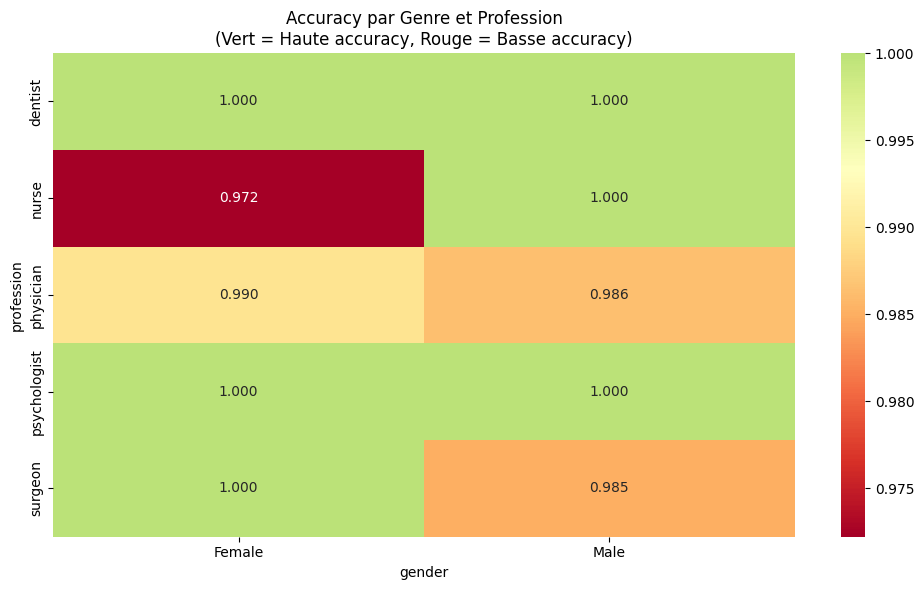

In [22]:
# Cellule 6: Analyse intersectionnelle
def analyze_intersectionality():
    """Analyser biais Genre × Profession"""
    print("🎭 ANALYSE INTERSECTIONNELLE (Genre × Profession)")
    print("=" * 50)
    
    # Créer tableau croisé des accuracies
    results = []
    
    for gender in ['Male', 'Female']:  # Utiliser les vraies valeurs du dataset
        for profession_id, profession in enumerate(le.classes_):
            # Masque pour ce sous-groupe
            gender_mask = genders == gender
            profession_mask = y_test == profession_id
            combined_mask = gender_mask & profession_mask
            
            if combined_mask.sum() > 0:
                # Accuracy pour ce sous-groupe
                accuracy = np.mean(test_pred[combined_mask] == y_test[combined_mask])
                
                results.append({
                    'gender': gender,
                    'profession': profession,
                    'count': combined_mask.sum(),
                    'accuracy': accuracy
                })
    
    # Convertir en DataFrame pour analyse
    intersect_df = pd.DataFrame(results)
    print(f"✅ {len(intersect_df)} sous-groupes analysés")
    
    # Créer tableau pivot
    pivot_accuracy = intersect_df.pivot(index='profession', 
                                        columns='gender', 
                                        values='accuracy')
    
    pivot_count = intersect_df.pivot(index='profession', 
                                    columns='gender', 
                                    values='count')
    
    print("📊 ACCURACY PAR SOUS-GROUPE:")
    print(pivot_accuracy.round(3))
    
    print("\n📈 NOMBRE D'EXEMPLES PAR SOUS-GROUPE:")
    print(pivot_count)
    
    # Calculer les gaps les plus importants
    print("\n⚠️ GAPS D'ACCURACY LES PLUS IMPORTANTS:")
    for profession in pivot_accuracy.index:
        if not pd.isna(pivot_accuracy.loc[profession, 'Male']) and not pd.isna(pivot_accuracy.loc[profession, 'Female']):
            gap = abs(pivot_accuracy.loc[profession, 'Male'] - pivot_accuracy.loc[profession, 'Female'])
            print(f"  {profession}: {gap:.3f}")
            
            if gap > 0.1:  # Gap > 10%
                better_gender = 'Male' if pivot_accuracy.loc[profession, 'Male'] > pivot_accuracy.loc[profession, 'Female'] else 'Female'
                print(f"    🚨 DISCRIMINATION: {better_gender} favorisé(e) de {gap:.1%}")
    
    # Visualisation heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_accuracy, annot=True, fmt='.3f', cmap='RdYlGn', 
               center=pivot_accuracy.mean().mean())
    plt.title('Accuracy par Genre et Profession\n(Vert = Haute accuracy, Rouge = Basse accuracy)')
    plt.tight_layout()
    plt.show()
    
    return intersect_df

intersect_results = analyze_intersectionality()

## 📈 Tests Statistiques de Significativité

In [23]:
# Cellule 7: Tests statistiques
def statistical_significance_tests():
    """Tests statistiques pour vérifier la significativité des biais"""
    print("📈 TESTS STATISTIQUES DE SIGNIFICATIVITÉ")
    print("=" * 45)
    
    # Test Chi2 pour indépendance genre/prédictions
    contingency_table = pd.crosstab(genders, test_pred)
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    
    print("1️⃣ TEST CHI2 - INDÉPENDANCE GENRE/PRÉDICTIONS:")
    print(f"  Chi2 statistic: {chi2:.4f}")
    print(f"  P-value: {p_value:.6f}")
    print(f"  Degrés de liberté: {dof}")
    
    if p_value < 0.001:
        print("  TRÈS SIGNIFICATIF (p < 0.001) - Forte dépendance genre/prédictions")
    elif p_value < 0.01:
        print("  ⚠️ SIGNIFICATIF (p < 0.01) - Dépendance genre/prédictions")
    elif p_value < 0.05:
        print("  ⚠️ Significatif (p < 0.05) - Dépendance genre/prédictions")
    else:
        print("  ✅ Non significatif - Pas de dépendance détectée")
    
    # Test t pour différence d'accuracy
    male_mask = genders == 'Male'
    female_mask = genders == 'Female'
    
    male_correct = (test_pred[male_mask] == y_test[male_mask]).astype(int)
    female_correct = (test_pred[female_mask] == y_test[female_mask]).astype(int)
    
    if len(male_correct) > 0 and len(female_correct) > 0:
        t_stat, t_p_value = stats.ttest_ind(male_correct, female_correct)
        
        print(f"\n2️⃣ TEST T - DIFFÉRENCE D'ACCURACY:")
        print(f"  Male accuracy: {np.mean(male_correct):.4f}")
        print(f"  Female accuracy: {np.mean(female_correct):.4f}")
        print(f"  T-statistic: {t_stat:.4f}")
        print(f"  P-value: {t_p_value:.6f}")
        
        if t_p_value < 0.05:
            print("  🚨 SIGNIFICATIF - Différence d'accuracy significative entre genres")
        else:
            print("  ✅ Non significatif - Pas de différence significative")
    
    # Bootstrap confidence intervals
    print(f"\n3️⃣ INTERVALLES DE CONFIANCE (Bootstrap):")
    n_bootstrap = 1000
    bootstrap_gaps = []
    
    for _ in range(n_bootstrap):
        # Échantillonnage avec remplacement
        indices = np.random.choice(len(y_test), len(y_test), replace=True)
        
        boot_genders = genders[indices]
        boot_pred = test_pred[indices]
        boot_true = y_test[indices]
        
        # Calculer accuracy par genre
        male_acc = np.mean((boot_pred == boot_true)[boot_genders == 'Male'])
        female_acc = np.mean((boot_pred == boot_true)[boot_genders == 'Female'])
        
        bootstrap_gaps.append(abs(male_acc - female_acc))
    
    # Intervalles de confiance
    ci_low = np.percentile(bootstrap_gaps, 2.5)
    ci_high = np.percentile(bootstrap_gaps, 97.5)
    
    print(f"  Gap d'accuracy observé: {abs(np.mean(male_correct) - np.mean(female_correct)):.4f}")
    print(f"  IC 95%: [{ci_low:.4f}, {ci_high:.4f}]")
    
    if ci_low > 0.05:  # Si l'intervalle est entièrement au-dessus de 5%
        print("  🚨 BIAIS ROBUSTE - Le gap est statistiquement significatif et > 5%")
    else:
        print("  ✅ Gap non robuste ou acceptable")

statistical_significance_tests()

📈 TESTS STATISTIQUES DE SIGNIFICATIVITÉ
1️⃣ TEST CHI2 - INDÉPENDANCE GENRE/PRÉDICTIONS:
  Chi2 statistic: 237.4011
  P-value: 0.000000
  Degrés de liberté: 4
  TRÈS SIGNIFICATIF (p < 0.001) - Forte dépendance genre/prédictions

2️⃣ TEST T - DIFFÉRENCE D'ACCURACY:
  Male accuracy: 0.9935
  Female accuracy: 0.9889
  T-statistic: 0.7654
  P-value: 0.444240
  ✅ Non significatif - Pas de différence significative

3️⃣ INTERVALLES DE CONFIANCE (Bootstrap):
  Gap d'accuracy observé: 0.0046
  IC 95%: [0.0004, 0.0151]
  ✅ Gap non robuste ou acceptable


## 📝 Résumé et Conclusions

In [24]:
# Cellule 8: Résumé final
def generate_bias_summary():
    """Générer un résumé des biais détectés"""
    print("📝 RÉSUMÉ DE L'ANALYSE DE BIAIS")
    print("=" * 35)
    
    # Compter les violations par métrique
    dp_violations = sum(1 for metrics in dp_results.values() if metrics['gap'] > 0.1)
    eo_violations = sum(1 for metrics in eo_results.values() if metrics['gap'] > 0.1)
    eqodds_violations = sum(1 for metrics in eqodds_results.values() if metrics['max_gap'] > 0.1)
    
    print(f"🎯 MODÈLE ANALYSÉ: TF-IDF + Random Forest")
    print(f"📊 TEST SET: {len(df_test)} exemples")
    print(f"⚖️ ATTRIBUT PROTÉGÉ: Genre (Male/Female)")
    
    print(f"\n🚨 VIOLATIONS DÉTECTÉES (seuil 10%):")
    print(f"  Demographic Parity: {dp_violations}/{len(dp_results)} professions")
    print(f"  Equality of Opportunity: {eo_violations}/{len(eo_results)} professions")
    print(f"  Equalized Odds: {eqodds_violations}/{len(eqodds_results)} professions")
    
    total_violations = dp_violations + eo_violations + eqodds_violations
    total_possible = len(dp_results) * 3
    
    print(f"\n📈 SCORE DE FAIRNESS:")
    fairness_score = 1 - (total_violations / total_possible)
    print(f"  {fairness_score:.2%} (1.0 = parfaitement équitable)")
    
    if fairness_score < 0.7:
        print(f"  🚨 MODÈLE TRÈS BIAISÉ - Nécessite mitigation urgente")
    elif fairness_score < 0.85:
        print(f"  ⚠️ MODÈLE MODÉRÉMENT BIAISÉ - Mitigation recommandée")
    else:
        print(f"  ✅ MODÈLE RELATIVEMENT ÉQUITABLE")
    
    # Identifier les professions les plus problématiques
    print(f"\n⚠️ PROFESSIONS LES PLUS BIAISÉES:")
    profession_bias_scores = {}
    
    for prof in le.classes_:
        violations = 0
        if prof in dp_results and dp_results[prof]['gap'] > 0.1:
            violations += 1
        if prof in eo_results and eo_results[prof]['gap'] > 0.1:
            violations += 1
        if prof in eqodds_results and eqodds_results[prof]['max_gap'] > 0.1:
            violations += 1
        
        profession_bias_scores[prof] = violations
    
    # Trier par nombre de violations
    sorted_profs = sorted(profession_bias_scores.items(), key=lambda x: x[1], reverse=True)
    
    for prof, violations in sorted_profs[:3]:  # Top 3
        print(f"  {prof}: {violations}/3 métriques violées")
    
    print(f"\n🎯 PROCHAINES ÉTAPES:")
    print(f"  1. Analyser feature importance pour identifier sources de biais")
    print(f"  2. Tester techniques de mitigation (resampling, fairness constraints)")
    print(f"  3. Comparer avec modèles alternatifs (BERT, RoBERTa)")
    print(f"  4. Implémenter post-processing pour égaliser les seuils")
    
    return {
        'fairness_score': fairness_score,
        'total_violations': total_violations,
        'most_biased_professions': sorted_profs[:3]
    }

summary = generate_bias_summary()

# Sauvegarder les résultats
bias_analysis_results = {
    'demographic_parity': dp_results,
    'equality_opportunity': eo_results,
    'equalized_odds': eqodds_results,
    'intersectionality': intersect_results.to_dict('records'),
    'summary': summary
}

with open('bias_analysis_results.pkl', 'wb') as f:
    pickle.dump(bias_analysis_results, f)

print(f"\n💾 Résultats sauvegardés dans: bias_analysis_results.pkl")
print(f"\n🎉 ANALYSE DE BIAIS TERMINÉE!")

📝 RÉSUMÉ DE L'ANALYSE DE BIAIS
🎯 MODÈLE ANALYSÉ: TF-IDF + Random Forest
📊 TEST SET: 1000 exemples
⚖️ ATTRIBUT PROTÉGÉ: Genre (Male/Female)

🚨 VIOLATIONS DÉTECTÉES (seuil 10%):
  Demographic Parity: 3/5 professions
  Equality of Opportunity: 0/5 professions
  Equalized Odds: 0/5 professions

📈 SCORE DE FAIRNESS:
  80.00% (1.0 = parfaitement équitable)
  ⚠️ MODÈLE MODÉRÉMENT BIAISÉ - Mitigation recommandée

⚠️ PROFESSIONS LES PLUS BIAISÉES:
  dentist: 1/3 métriques violées
  nurse: 1/3 métriques violées
  surgeon: 1/3 métriques violées

🎯 PROCHAINES ÉTAPES:
  1. Analyser feature importance pour identifier sources de biais
  2. Tester techniques de mitigation (resampling, fairness constraints)
  3. Comparer avec modèles alternatifs (BERT, RoBERTa)
  4. Implémenter post-processing pour égaliser les seuils

💾 Résultats sauvegardés dans: bias_analysis_results.pkl

🎉 ANALYSE DE BIAIS TERMINÉE!
